# Offset Analysis

Analyses of the per-frame, per-chunk detector offsets produced by the self-calibration
pipeline (`SelfCal.PipelineWrapper.Calibrator`, driven by `selfcal_scripts/run_cal_v2.py`).

**Calibration file layout** (written by `Calibrator.save_calibration`):

- `offset`: `(num_frames, num_chunks)` — per-frame, per-chunk additive offsets.
  `num_chunks = (NUM_SUB * NUM_CH + 2) * NUM_COL`; chunks index (subchannel-arc, column-strip) tiles on the detector.
- `skymap`: solved sky image on the reference WCS grid.
- `reproj_list`: per-frame source paths (indexed along axis 0 of `offset`).
- `skymap_coverage`, `offset_coverage`, `offset_coverage_frac`: coverage diagnostics.

Sections below:

1. **Multi-Channel Offset Stitching** — combine per-channel calibration runs into a continuous offset vs. wavelength.
2. **Stitched Offset vs. Raw Mean Pixel Value** — compare the recovered offsets to the naive per-chunk mean.
3. **2D Interpolated Detector Offset Map** — render the stitched offset back onto the detector plane.
4. **Mean Offset per Exposure (Temporal & Spatial)** — frame-averaged offset vs. time / sky position, with sine fits.
5. **Per-Chunk Offset Analysis** — per-chunk centroid in (x, y, t), spatially binned sine fits, phase maps.


## Setup

In [1]:
import glob
import os
import h5py
from pandas import DataFrame
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400 # User can set this outside the class if needed

from astropy.io import fits
from astropy.io.votable import parse_single_table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u

import os
import h5py
from tqdm import tqdm
from multiprocessing import Pool 
from concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutor
import numpy as np

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.table import Table

from reproject import reproject_interp
from reproject import reproject_exact
from reproject import reproject_adaptive

from scipy.sparse import coo_matrix
from scipy.sparse.linalg import lsqr
import sys 
import gc 
from functools import partial
from IPython.display import clear_output

from SelfCal.MapHelper import bit_to_bool, make_weight, find_outliers, map_pixels
from SelfCal.WCSHelper import load_from_fits, save_to_fits, find_optimal_frame
from SelfCal import MakeMap
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, make_fiducial_chunk_mask, interpolate_array, load_calibration, interp_2d_vertical, interp_1d, \
    make_spherex_stripped_offset_map, load_lvf_params, make_stripped_chunk_map, make_stripped_chunk_valid_mask, compute_offsets_guess
from SelfCal.MakeMap import load_reproj_file
import importlib
importlib.reload(MakeMap)

from datetime import datetime
import pandas as pd


In [2]:
def plot_map(map, wcs=None, lowp=0.1, highp=95, fig=None, ax=None, colorbar=True, low=None, high=None, cmap='viridis', norm=LogNorm,
            cbar_label='MJy/sr'):
    if low is None or high is None:
        high, low = np.nanpercentile(map[map>0], [highp, lowp])
    if fig is None:
        fig = plt.figure(figsize=(10, 10))
    if ax is None:
        ax = fig.add_subplot(111, projection=wcs)
    if norm is LogNorm:
        im = ax.imshow(map, norm=LogNorm(vmin=low, vmax=high), origin='lower', cmap=cmap)
    else:
        im = ax.imshow(map, vmin=low, vmax=high, origin='lower', cmap=cmap)

    if wcs is not None:
        # Explicitly set axis labels
        ax.coords['ra'].set_axislabel('RA')
        ax.coords['ra'].set_axislabel_position('b')  # Ensure RA label is only at the bottom
        ax.coords['ra'].set_ticks_position('b')  # Set RA ticks only at the bottom
        ax.coords['ra'].set_ticklabel_position('b')  # Set RA tick labels only at the bottom
        ax.coords['dec'].set_axislabel('DEC')
        ax.grid(color='black', linestyle='--', alpha=0.5)

    if colorbar:
        cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.040, pad=0.04)
        cbar.set_label(cbar_label)
    return fig, ax

## Configuration & Chunk Maps

Detector geometry, LVF arc parameters, and chunk maps used by every downstream section.
`det_chunk_map` is the detector-resolution map (for subframe evaluation); `grid_chunk_map` is the
oversampled reference-grid map (used by the mosaicker).


In [3]:
DETECTOR = 4
OVERSAMPLE_FACTOR = 2
NUM_SUBCHANNELS = 10
NUM_CHANNELS = 34
NUM_COLUMNS = 3

lvf_filename = f'lvf_params_D{DETECTOR}.npy'
lvf_params = load_lvf_params(lvf_filename)

grid_chunk_map, _, _, _ = make_stripped_chunk_map(DETECTOR, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, num_columns=NUM_COLUMNS,
                                                oversample_factor=OVERSAMPLE_FACTOR, lvf_params=lvf_params)
det_chunk_map, _, r_edges, x_edges = make_stripped_chunk_map(DETECTOR, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, num_columns=NUM_COLUMNS,
                                           oversample_factor=1, lvf_params=lvf_params)


Loaded LVF parameters from /home/thomasli/spherex/selfcal/selfcal_scripts/lvf_params/lvf_params_D4.npy


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:02<00:00, 134.71it/s]


Spectral calibration maps (`BC` = band-center wavelength, `BW` = band-width)
and the fiducial subchannel map for the detector.


In [4]:
BC_map, BW_map = load_calibration(4, calibration_dir='/data3/thomasli/SPHEREx_Spectral_Calibration')
subchannel_map, _, _ = make_fiducial_chunk_map(4, BC_map, num_channels=34, num_subchannels=10, 
                            channel_file='/home/thomasli/spherex/spherex_channels.csv', 
                            oversample_factor=1, lvf_params=lvf_params)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:02<00:00, 139.63it/s]


## 1. Multi-Channel Offset Stitching

Each calibration run solves for offsets within a single active channel (plus one subchannel of
padding on either side, for continuity). Stitching walks through the per-channel offset cubes
and uses the shared padded subchannels between neighbours to compute a running additive
correction, yielding one continuous offset spectrum across all channels.

In [5]:
DETECTOR = 5
NUM_SUBCHANNELS = 10
NUM_CHANNELS = 34
NUM_COLUMNS = 3

cal_dir = f'/mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det{DETECTOR}_6p2arcsec/calibration/'
cal_file_template = 'cal_Detector{DETECTOR}_NumSub10_NumCh34_NumCol3_Ch{ch}_damp0p1_reg0p1_outThresh5_sigma2.h5'.replace('{DETECTOR}', str(DETECTOR))   

lvf_filename = f'/home/thomasli/spherex/selfcal/selfcal_scripts/lvf_params/lvf_params_D{DETECTOR}.npy'
lvf_params = load_lvf_params(lvf_filename)

sample_ch = 1

sample_chunk_mask = make_stripped_chunk_valid_mask(ch=[sample_ch], num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                        num_columns=NUM_COLUMNS, subchannel_padding=1)

cal_path = cal_dir + cal_file_template.replace('{ch}', str(sample_ch))
with h5py.File(cal_path, 'r') as f:
    reproj_list = f['reproj_list'][:]
    offset_shape = f['offset'].shape

reproj_list = [item.decode('utf-8') for item in reproj_list]
exposure_list = [load_reproj_file(f, fields=['file_path'])['file_path'] for f in tqdm(reproj_list)]


Loaded LVF parameters from /home/thomasli/spherex/selfcal/selfcal_scripts/lvf_params/lvf_params_D5.npy


  0%|                                                                                                                | 0/12841 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 12841/12841 [00:03<00:00, 4011.82it/s]


In [6]:
chs = np.arange(1, 20)
offset_cube = np.zeros((len(chs), *offset_shape))
padded_mask_cube = np.zeros((len(chs), len(sample_chunk_mask)))
mask_cube = np.zeros((len(chs), len(sample_chunk_mask)))

for i, ch in enumerate(tqdm(chs)):
    cal_path = cal_dir + cal_file_template.replace('{ch}', str(ch))
    with h5py.File(cal_path, 'r') as f:
        offset = f['offset'][:]
    padded_chunk_mask = make_stripped_chunk_valid_mask(ch=[ch], num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                        num_columns=NUM_COLUMNS, subchannel_padding=1)
    chunk_mask = make_stripped_chunk_valid_mask(ch=[ch], num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                        num_columns=NUM_COLUMNS, subchannel_padding=0)
    
    offset_cube[i] = offset
    padded_mask_cube[i] = padded_chunk_mask
    mask_cube[i] = chunk_mask

combined_offset = np.zeros(offset_shape)
off = 0
for i in range(0, len(offset_cube)):
    valid_mask = mask_cube[i]
    if i != 0:
        prev_mask = padded_mask_cube[i-1]
        curr_mask = padded_mask_cube[i]
        share_mask = prev_mask * curr_mask
        diff = offset_cube[i][:, share_mask.astype(bool)] - offset_cube[i-1][:, share_mask.astype(bool)]
        off += np.mean(diff)

    combined_offset[:, valid_mask.astype(bool)] = off+offset_cube[i][ :, valid_mask.astype(bool)]

subchannel_offset = combined_offset.reshape(combined_offset.shape[0],342, 3).mean(axis=2)[:,1:-1]
mean_wav = (lvf_params['wave_edges'][:-1] + lvf_params['wave_edges'][1:])/2


  0%|                                                                                                                   | 0/19 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:32<00:00,  1.73s/it]


In [170]:
# plt.plot(mean_wav, subchannel_offset.mean(axis=0))

## 2. Stitched Offset vs. Raw Mean Pixel Value per Chunk

Sanity check: the stitched offset should track the naive per-chunk mean of the raw detector
frame (modulo a constant). `compute_offsets_guess` bins one exposure's pixel values by
`subchannel_map` and returns the per-subchannel mean.


In [ ]:
full_chunk_mask = make_fiducial_chunk_mask(np.hstack(chs), num_channels=34, num_subchannels=10, padding=0)
mean_pixval = compute_offsets_guess(reproj_list[0:1], subchannel_map) 
valid_mean_pixval = mean_pixval[:, full_chunk_mask.astype(bool)]

In [ ]:
plt.plot(mean_wav, subchannel_offset[0])
plt.plot(mean_wav, valid_mean_pixval[0])

## 3. 2D Interpolated Detector Offset Map

Render the mean stitched offset back onto the 2040×2040 detector plane using
`make_spherex_stripped_offset_map`, which fits a 2D mean-preserving spline over
(R, x) and evaluates it on the pixel grid. Each channel's contribution is masked to
its valid subchannels and summed.


In [ ]:
tot_subchannels = NUM_CHANNELS*NUM_SUBCHANNELS+2

In [ ]:
det_full_offset = np.zeros((2040,2040))
for i in range(7):

    partial_make_offset_map = partial(make_spherex_stripped_offset_map,
        chunk_valid_mask=chunk_valid_mask_list[i], 
        lvf_params=lvf_params, 
        r_edges=r_edges, 
        x_edges=x_edges, 
        tot_subchannels=tot_subchannels, 
        num_columns=NUM_COLUMNS,
        fill_invalid=True)

    sample_offset = np.mean(offset_list[i], axis=0)
    det_valid_mask = chunk_valid_mask_list[i][det_chunk_map]
    sample_offset_interp = partial_make_offset_map(chunk_map=det_chunk_map, chunk_offset=sample_offset) * det_valid_mask
    det_full_offset += sample_offset_interp

In [ ]:
plt.imshow(np.where(det_full_offset>0, det_full_offset, np.nan))
plt.colorbar()

## 4. Mean Offset per Exposure (Temporal & Spatial)

Average each frame's valid offsets down to a single scalar and correlate with exposure
metadata (MJD-AVG, CRVAL1/CRVAL2) pulled from the source FITS headers.


In [7]:
import pandas as pd
from astropy.io import fits
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

def process_single_file(reproj_path):
    """Worker function to process one file."""
    try:
        reproj_data = load_reproj_file(reproj_path, fields=['file_path', 'sub_mapping'])
        exposure_file = reproj_data['file_path']
        
        with fits.open(exposure_file) as hdul:
            header = hdul[1].header
            return {
                'CRVAL1': header.get('CRVAL1'),
                'CRVAL2': header.get('CRVAL2'),
                'MJD-AVG': header.get('MJD-AVG')
            }
    except Exception:
        return None

# --- Execution ---
columns = ['CRVAL1', 'CRVAL2', 'MJD-AVG']
num_workers = 10 

# We wrap the executor.map in tqdm to track progress
with ProcessPoolExecutor(max_workers=num_workers) as executor:
    # chunksize=20 reduces the overhead of task distribution
    results = list(tqdm(
        executor.map(process_single_file, reproj_list, chunksize=10), 
        total=len(reproj_list),
        desc="Processing FITS Headers"
    ))

# Filter out None results and build DF
df = pd.DataFrame([r for r in results if r is not None], columns=columns)

Processing FITS Headers: 100%|███████████████████████████████████████████████████████████████████████████| 12841/12841 [34:49<00:00,  6.14it/s]


In [9]:
time_sorted_indices = np.argsort(df['MJD-AVG'].values)
time_sorted_mjd = df['MJD-AVG'].values[time_sorted_indices]

df['mean_offset'] = subchannel_offset.mean(axis=1)

# for subch in range(subchannel_offset.shape[1]):
#     df[f'subch_{subch}_offset'] = subchannel_offset[:, subch]

In [33]:
from astropy.coordinates import SkyCoord

NEP_RA = 270 
NEP_DEC = 66.5
MAXIMUM_DISTANCE = 3*u.degree

nep_coord = SkyCoord(ra=NEP_RA*u.degree, dec=NEP_DEC*u.degree)
dist_from_nep = nep_coord.separation(SkyCoord(ra=df['CRVAL1'].values*u.degree, dec=df['CRVAL2'].values*u.degree))

condition = dist_from_nep < MAXIMUM_DISTANCE

### 4a. NEP center single channel fit

Restrict to pointings near the NEP center and fit an annual sinusoid (zodiacal modulation).


In [34]:
from scipy.optimize import curve_fit

def sine_func(t, A, f, phi, C):
    return A * np.sin(2 * np.pi * f * t + phi) + C

def fit_sine(x, y):
    
    guess_f = 1/365
    guess_A = 0.015
    guess_C = 0.145
    guess_phi = -9.7
    
    p0 = [guess_A, guess_f, guess_phi, guess_C]
    

    params, _ = curve_fit(
        sine_func, x, y, 
        p0=p0, 
        method='trf',      # Required for robust loss functions
        loss='soft_l1', 
        f_scale=0.1,        # Adjust based on the expected noise level
        max_nfev=5000
    )
        
    A, f, phi, C = params
    
    return C, A, phi, f

Rejected 1915 / 3969 points


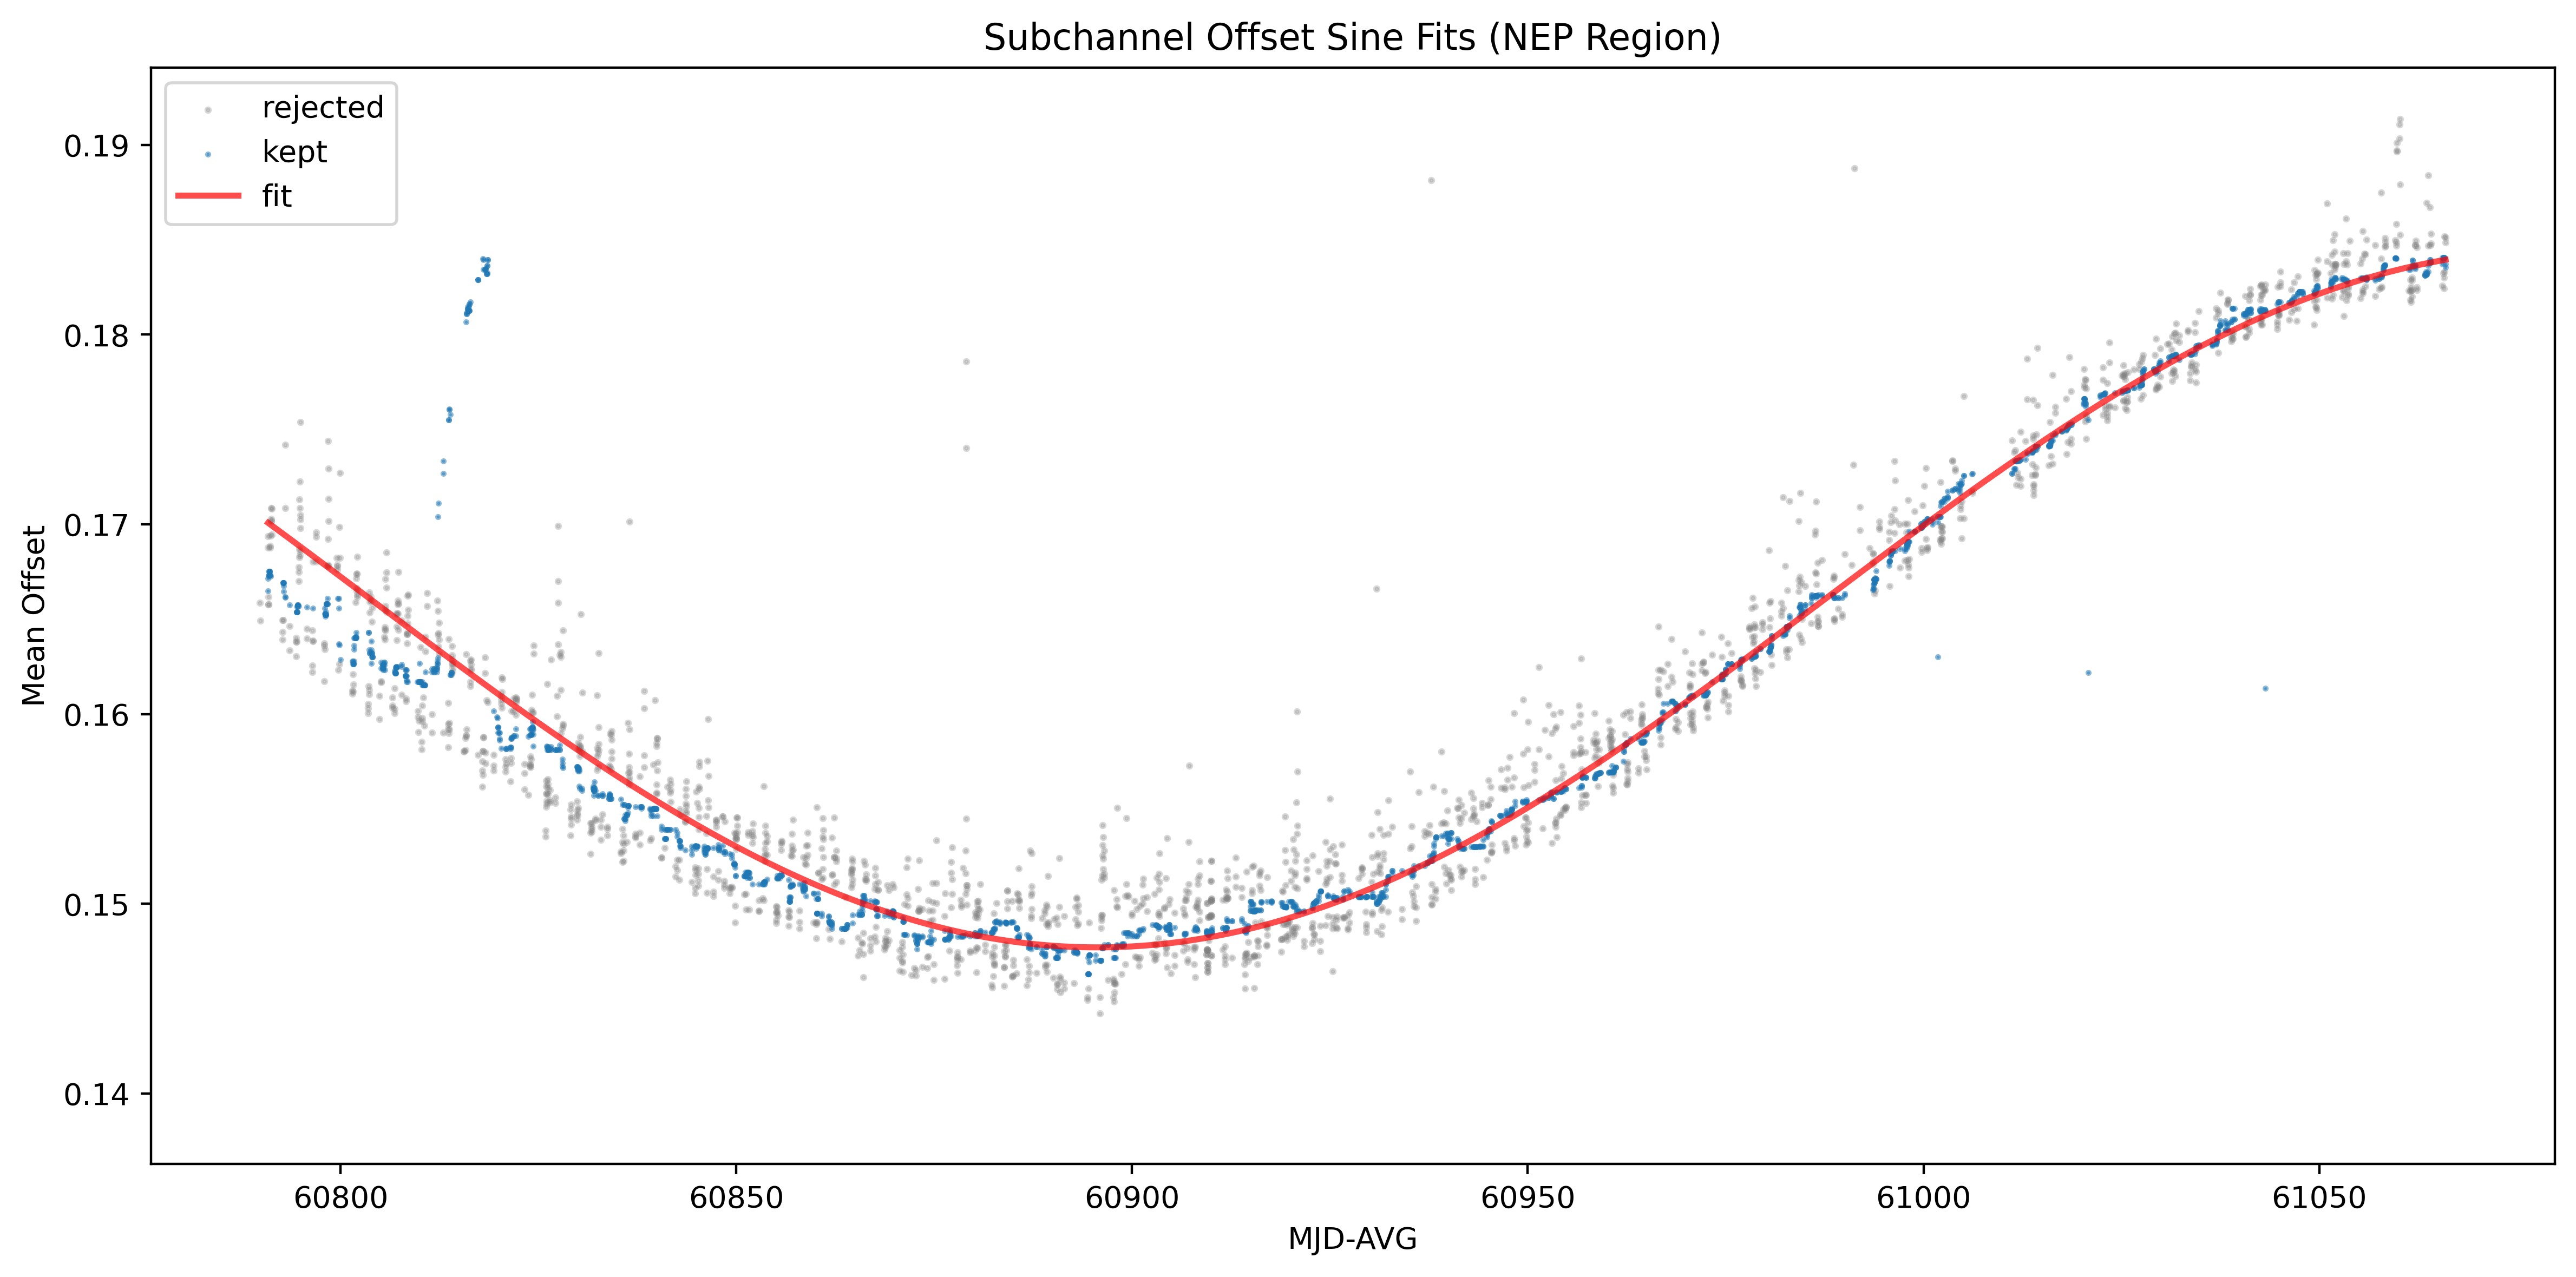

In [35]:
from scipy.signal import medfilt

def moving_window_sigma_reject(x, y, window=51, n_sigma=3, n_iter=2):
    """Reject outliers using a moving window around each point (sorted in x).
    Window is an odd integer giving the number of neighbors (incl. self)
    used to compute the local median and MAD-based sigma."""
    x = np.asarray(x)
    y = np.asarray(y)
    keep = np.ones(len(x), dtype=bool)

    for _ in range(n_iter):
        idx = np.argsort(x[keep])
        xs = x[keep][idx]
        ys = y[keep][idx]
        n = len(ys)
        if n < window:
            break

        half = window // 2
        local_med = np.empty(n)
        local_sigma = np.empty(n)
        for i in range(n):
            lo = max(0, i - half)
            hi = min(n, i + half + 1)
            w = ys[lo:hi]
            med = np.median(w)
            local_med[i] = med
            local_sigma[i] = 1.4826 * np.median(np.abs(w - med))

        bad_sorted = np.abs(ys - local_med) > n_sigma * local_sigma
        # map back to original indices
        keep_indices = np.nonzero(keep)[0][idx]
        keep[keep_indices[bad_sorted]] = False

        if not bad_sorted.any():
            break

    return keep

fig, ax = plt.subplots(figsize=(12, 6))
subch_index = 170

x_data = df['MJD-AVG'][condition].values
y_data = subchannel_offset[:, subch_index][condition]

keep = moving_window_sigma_reject(x_data, y_data, window=51, n_sigma=1, n_iter=2)
x_clean = x_data[keep]
y_clean = y_data[keep]
y_clean = medfilt(y_clean, kernel_size=11)
print(f'Rejected {np.sum(~keep)} / {len(keep)} points')

C, A, phi, f = fit_sine(x_clean, y_clean)
spl = partial(sine_func, C=C, A=A, phi=phi, f=f)
x_fit = np.linspace(x_clean.min(), x_clean.max(), 1000)
y_fit = spl(x_fit)

ax.scatter(x_data[~keep], y_data[~keep], s=2, alpha=0.3, color='gray', label='rejected')
ax.scatter(x_clean, y_clean, s=1, alpha=0.5, label='kept')
ax.plot(x_fit, y_fit, color='red', linewidth=2, alpha=0.7, label='fit')

ax.set_xlabel('MJD-AVG')
ax.set_ylabel('Mean Offset')
ax.set_title('Subchannel Offset Sine Fits (NEP Region)')
ax.legend()
plt.ylim(min(y_clean)-0.01, max(y_clean)+0.01)
plt.tight_layout()

### 4b. NEP center multi channel fit

Restrict to pointings near the NEP center and fit an annual sinusoid (zodiacal modulation).


In [17]:
from scipy.optimize import curve_fit


def bin_by_x(x, y, n_bins=50):
    """Median-bin y in equal-width x bins. Drops empty bins."""
    x = np.asarray(x)
    y = np.asarray(y)
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    idx = np.clip(np.digitize(x, edges) - 1, 0, n_bins - 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    y_out = np.full(n_bins, np.nan)
    for i in range(n_bins):
        m = idx == i
        if np.any(m):
            y_out[i] = np.median(y[m])
    valid = ~np.isnan(y_out)
    return centers[valid], y_out[valid]


def joint_sine_model(X, *params):
    """Shared (phi, f); per-subchannel (A_k, C_k).
    X is a (2, N) array: row 0 is time, row 1 is subchannel index
    (curve_fit coerces xdata to float, so we cast the index back to int).
    params = [phi, f, A_0..A_{K-1}, C_0..C_{K-1}]."""
    X = np.asarray(X)
    t = X[0]
    subch_idx = X[1].astype(int)
    phi, f = params[0], params[1]
    k = (len(params) - 2) // 2
    A = np.asarray(params[2:2 + k])
    C = np.asarray(params[2 + k:2 + 2 * k])
    return A[subch_idx] * np.sin(2 * np.pi * f * t + phi) + C[subch_idx]


def fit_joint_sine(t_list, y_list,
                   guess_A=0.015, guess_C=0.145,
                   guess_phi=-9.7, guess_f=1/365):
    """Fit all subchannels at once with shared phi, f and per-subchannel A, C."""
    n_sub = len(t_list)
    subch_idx = np.concatenate([np.full(len(t), i, dtype=int) for i, t in enumerate(t_list)])
    t_all = np.concatenate(t_list)
    y_all = np.concatenate(y_list)
    X = np.vstack([t_all, subch_idx.astype(float)])
    p0 = [guess_phi, guess_f] + [guess_A] * n_sub + [guess_C] * n_sub

    params, _ = curve_fit(
        joint_sine_model, X, y_all,
        p0=p0, method='trf', loss='soft_l1', f_scale=0.1, max_nfev=10000,
    )
    phi, f = params[0], params[1]
    A = np.asarray(params[2:2 + n_sub])
    C = np.asarray(params[2 + n_sub:2 + 2 * n_sub])
    return phi, f, A, C


n_subch = subchannel_offset.shape[1]
x_all = df['MJD-AVG'][condition].values

t_list, y_list = [], []
for subch_index in tqdm(range(n_subch), desc='clean+bin'):
    y_data = subchannel_offset[:, subch_index][condition]

    keep = moving_window_sigma_reject(x_all, y_data, window=51, n_sigma=1, n_iter=2)
    x_clean = x_all[keep]
    y_clean = y_data[keep]

    x_b, y_b = bin_by_x(x_clean, y_clean, n_bins=50)
    t_list.append(x_b)
    y_list.append(y_b)

phi, f, subchannel_A, subchannel_C = fit_joint_sine(t_list, y_list)
print(f'shared phi={phi:.4f}, f={f:.6f} (period={1/f:.2f} days)')

clean+bin: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 340/340 [00:40<00:00,  8.42it/s]


shared phi=-6.4843, f=0.002731 (period=366.12 days)


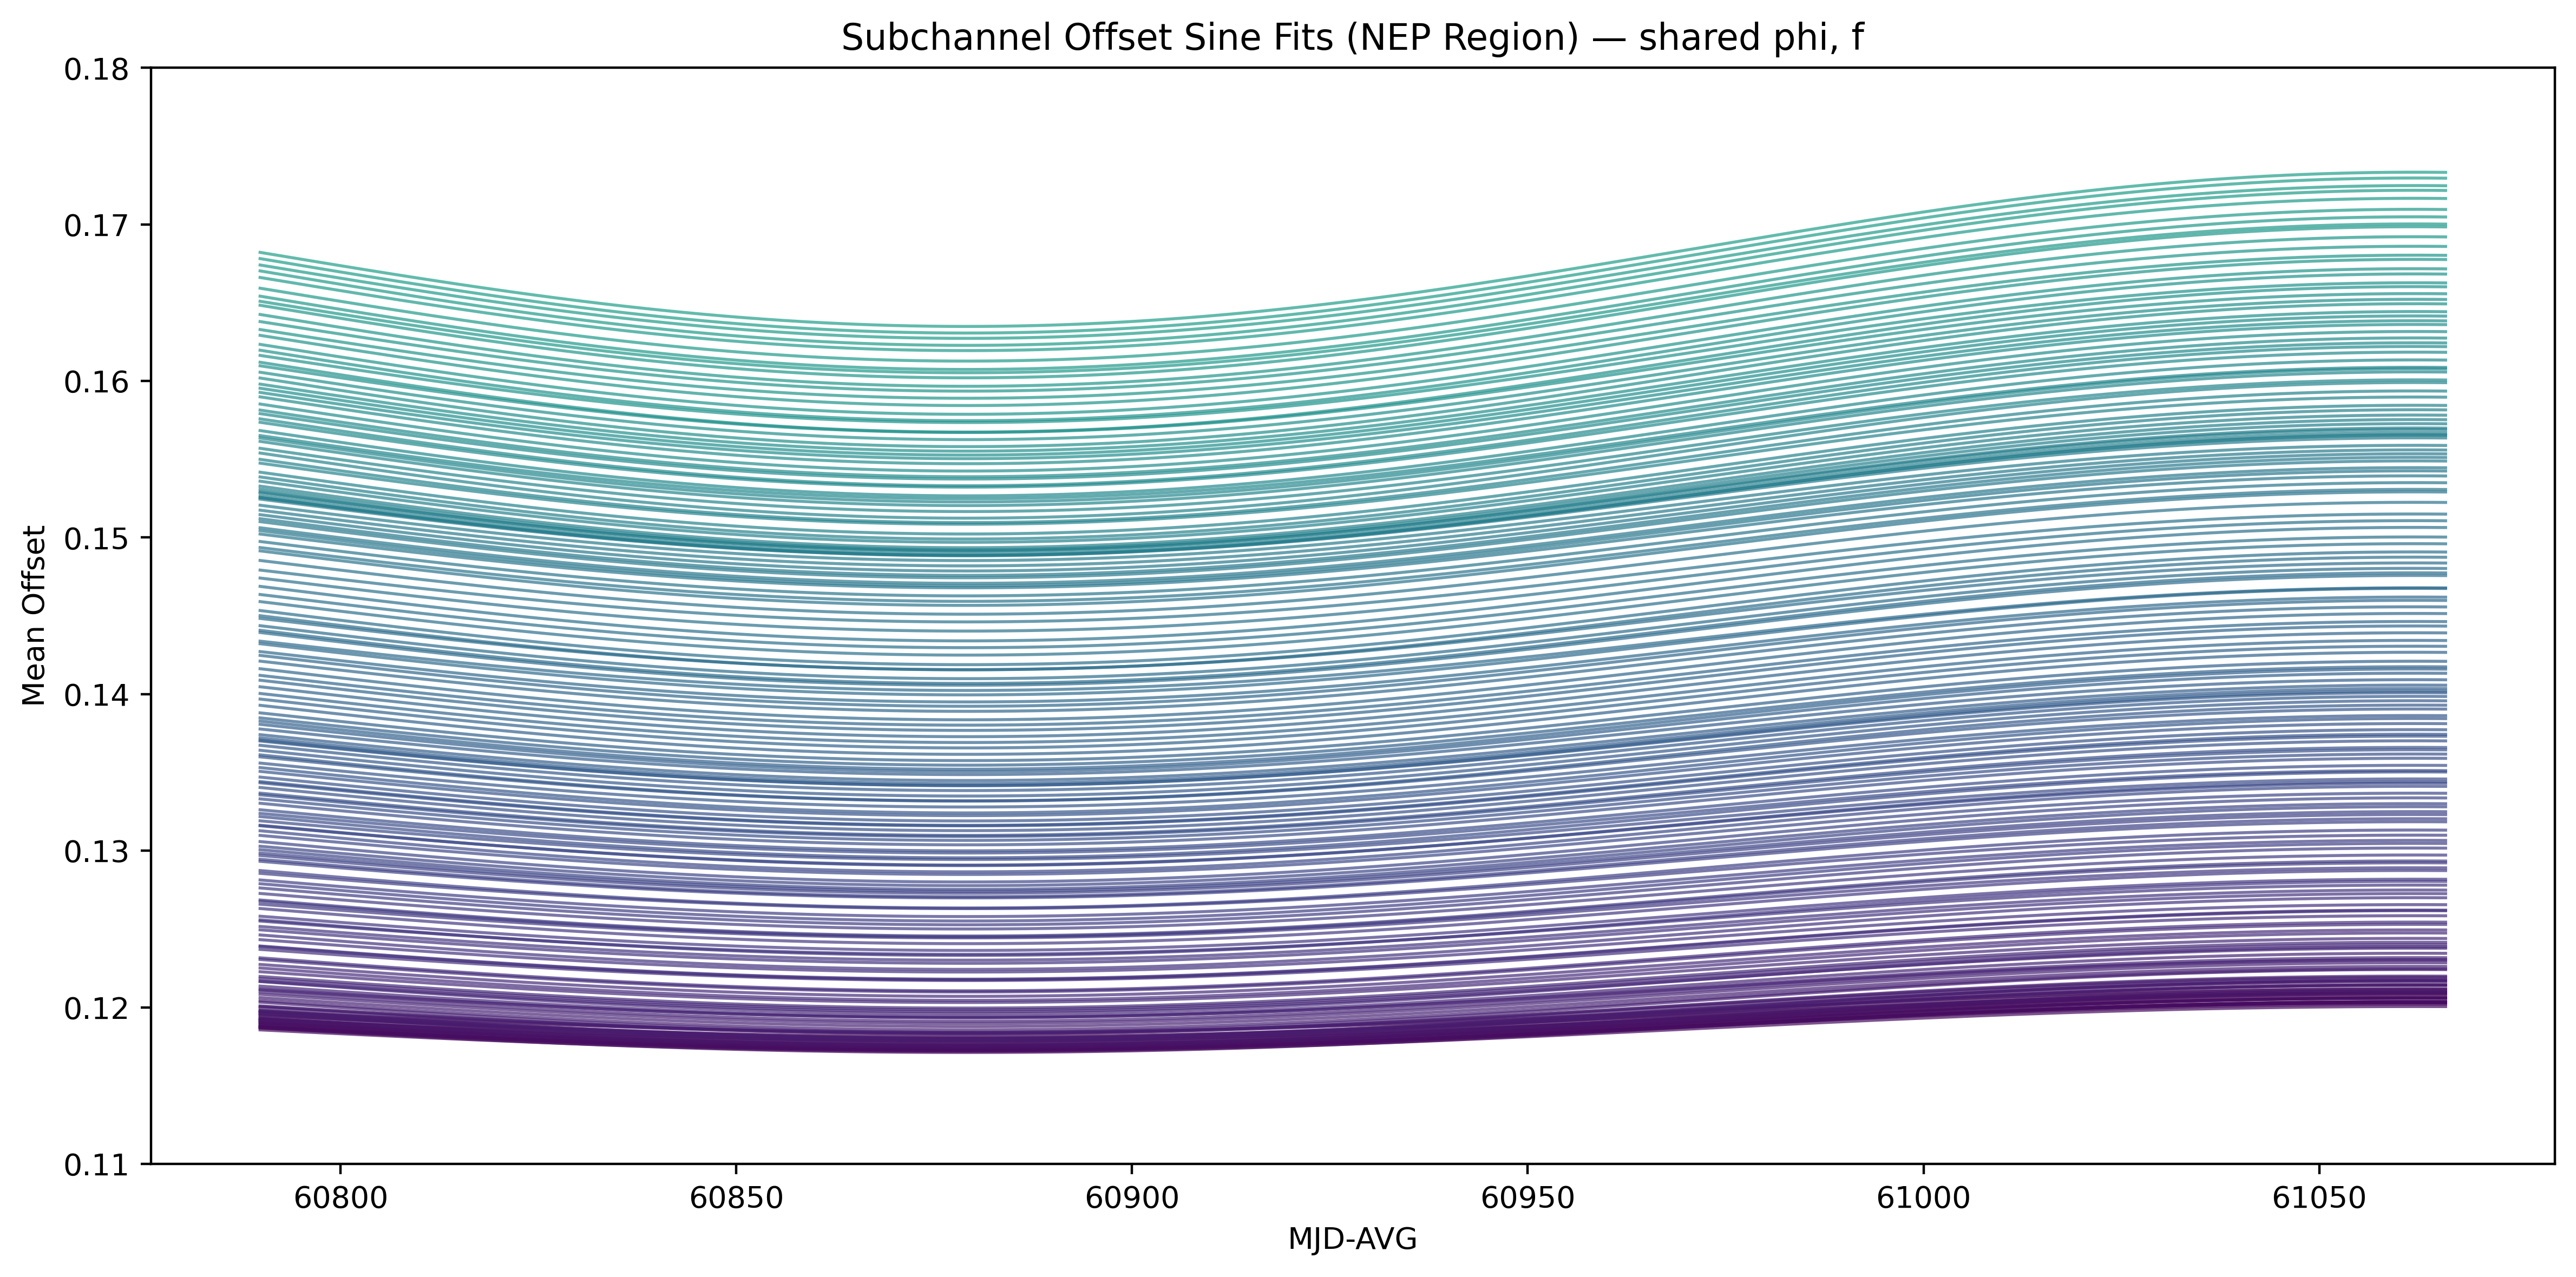

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
x_fit = np.linspace(x_all.min(), x_all.max(), 1000)
for subch_index in range(n_subch):
    y_fit = (subchannel_A[subch_index] * np.sin(2 * np.pi * f * x_fit + phi)
             + subchannel_C[subch_index])
    color = plt.cm.viridis(subch_index / n_subch)
    ax.plot(x_fit, y_fit, color=color, linewidth=1, alpha=0.7)

ax.set_xlabel('MJD-AVG')
ax.set_ylabel('Mean Offset')
ax.set_title('Subchannel Offset Sine Fits (NEP Region) — shared phi, f')
plt.ylim(0.11, 0.18)
plt.tight_layout()

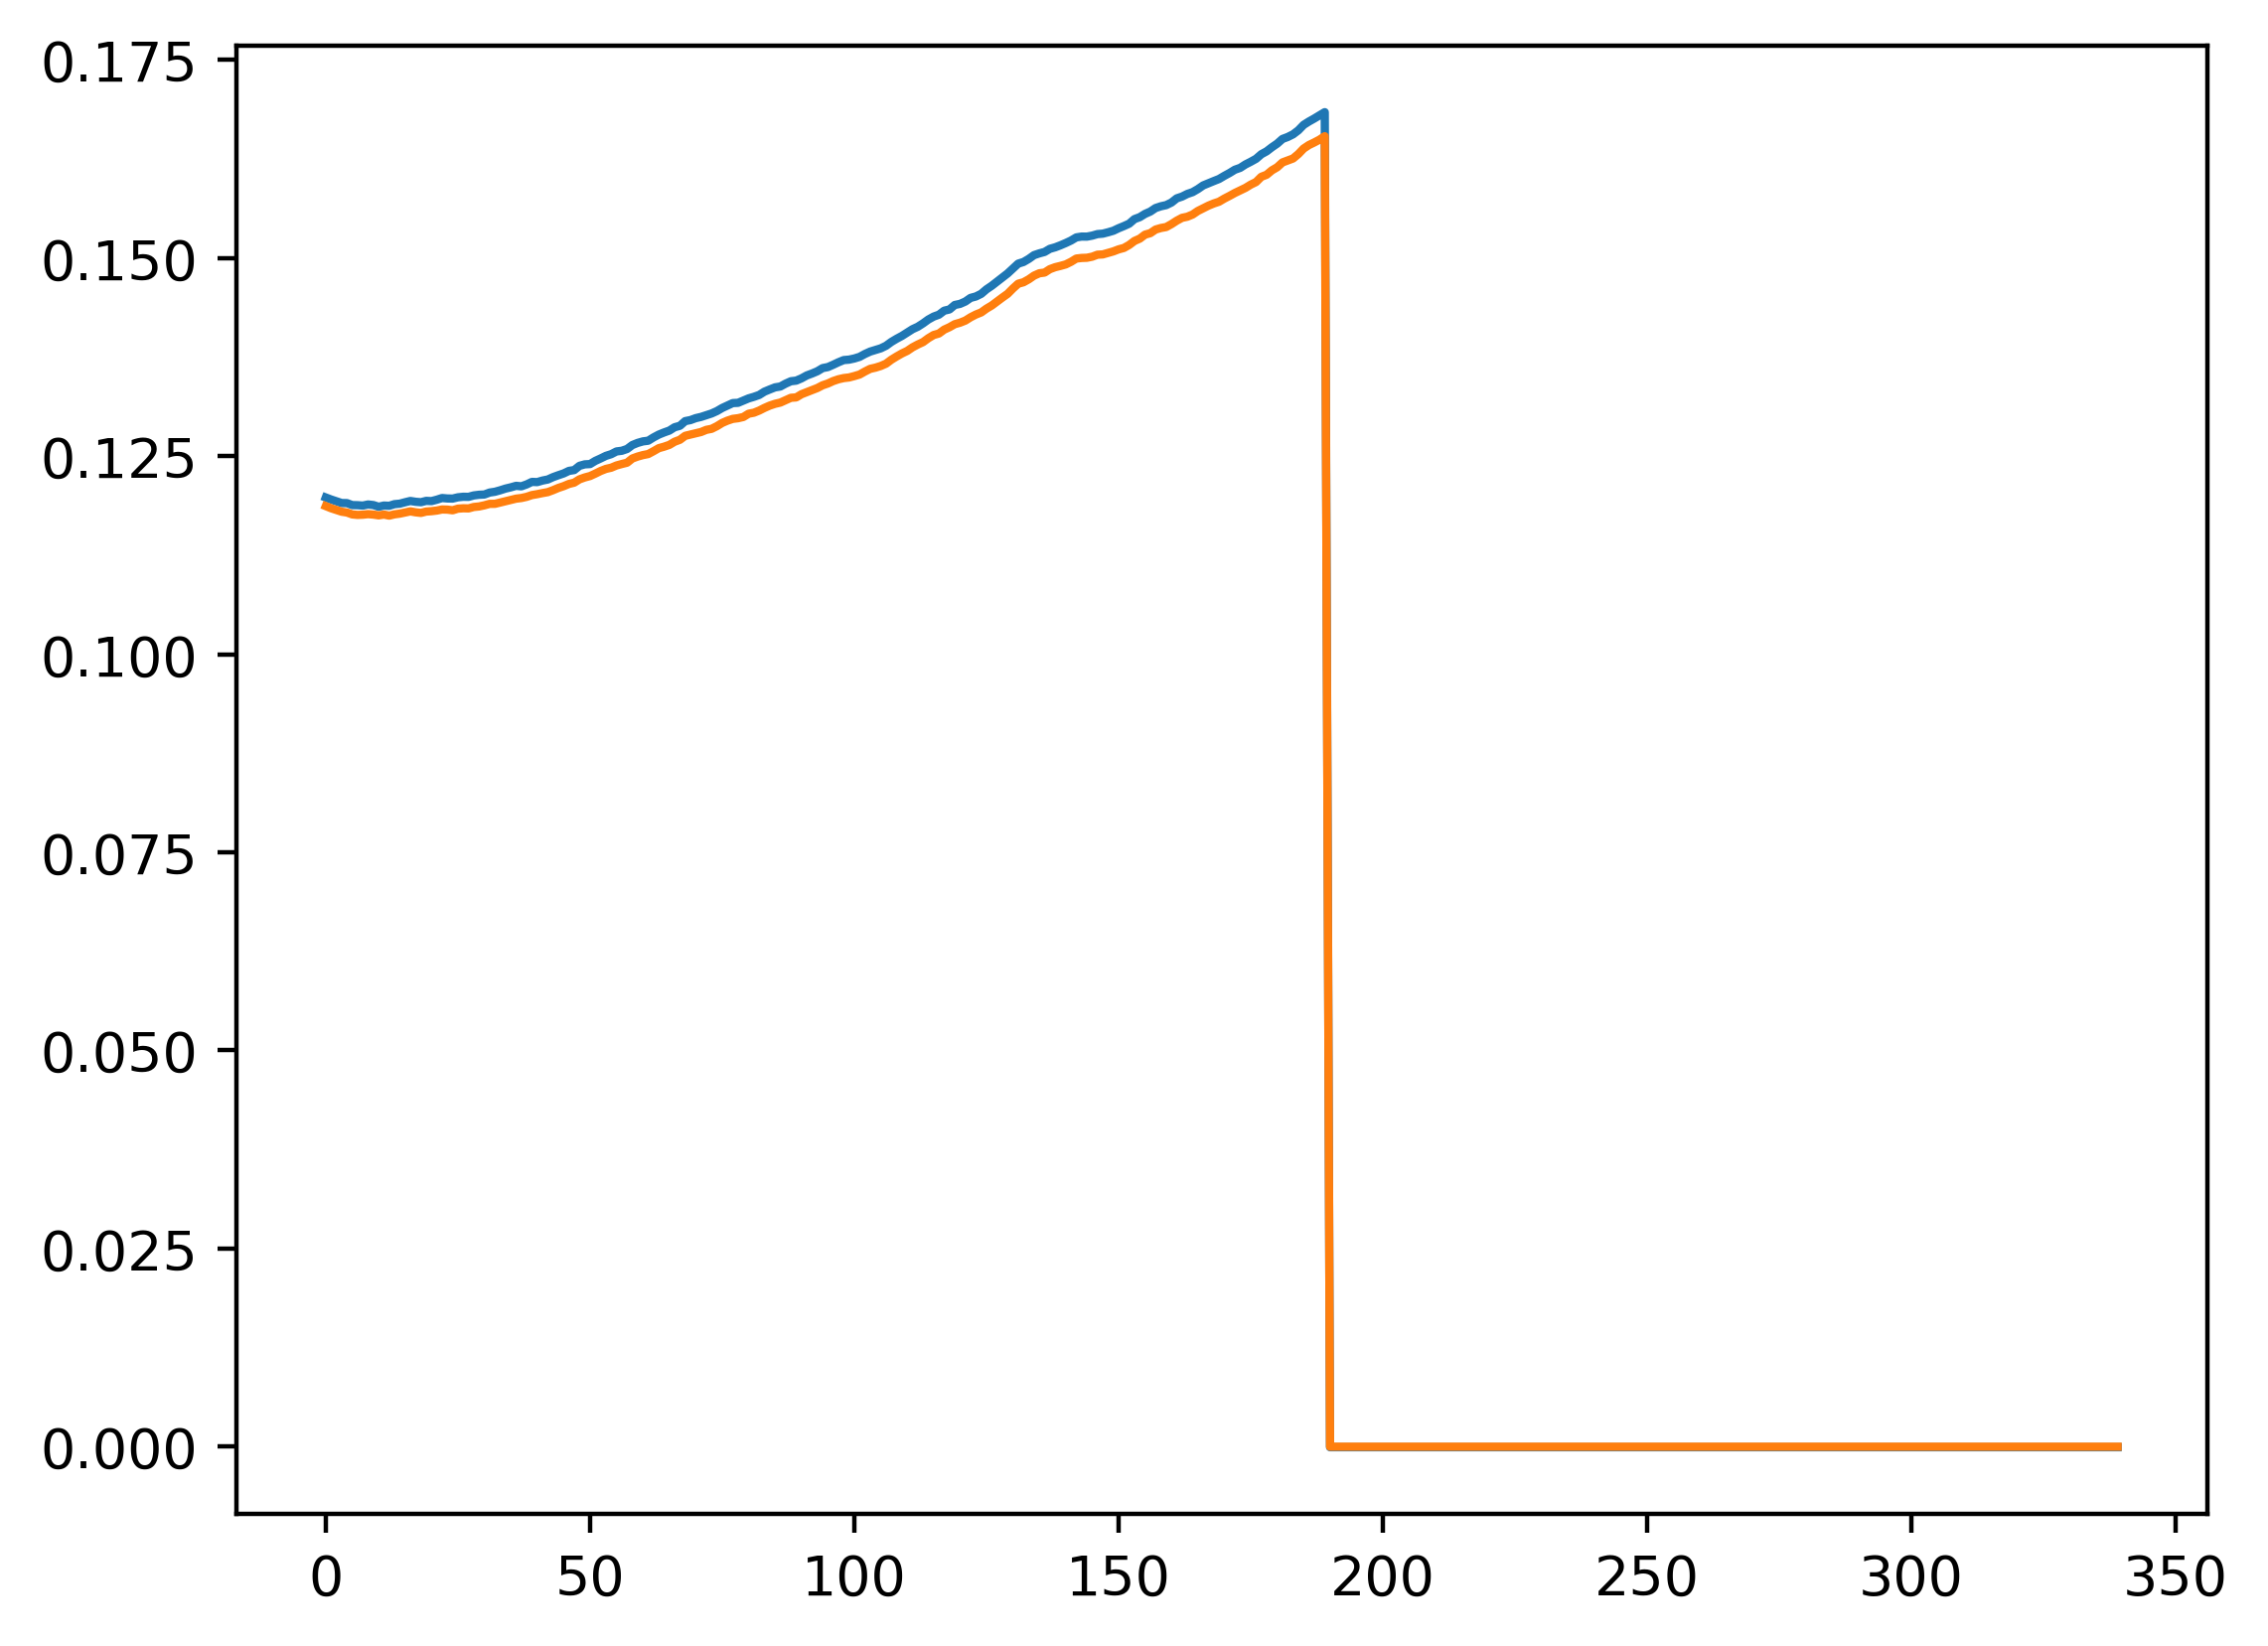

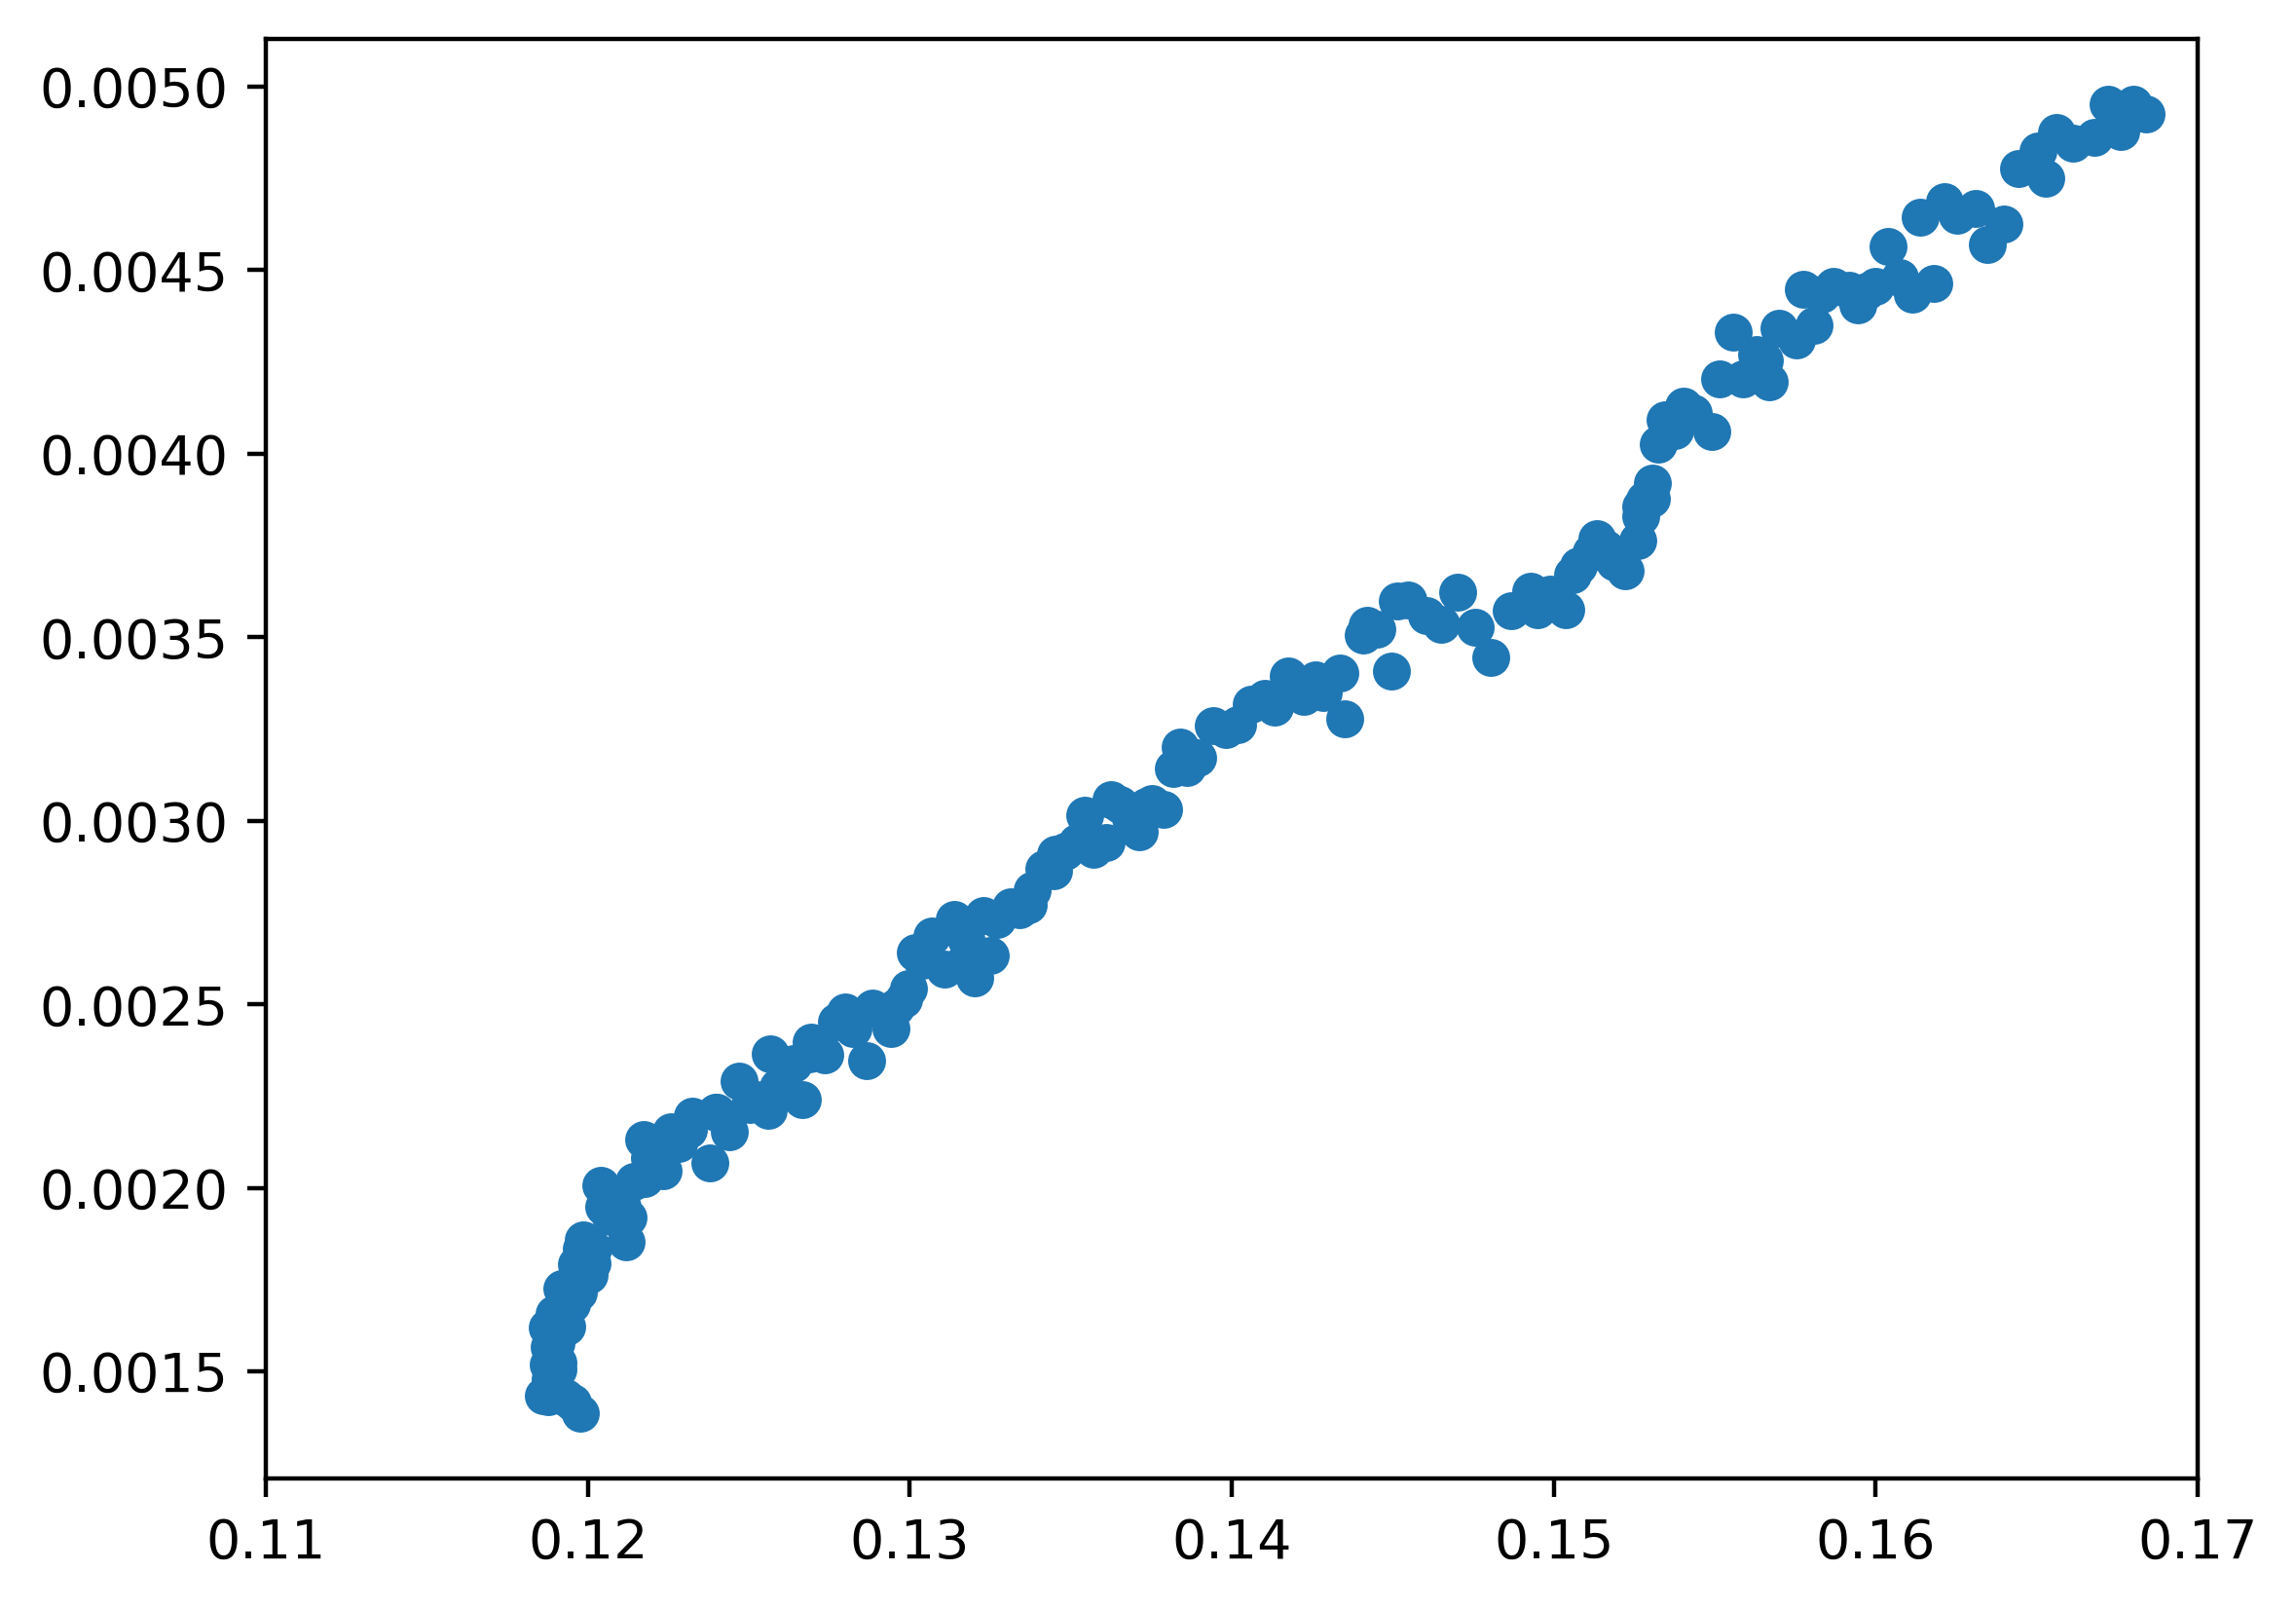

In [26]:
plt.plot(subchannel_C)
plt.plot(np.median(subchannel_offset, axis=0))
plt.show()

plt.scatter(subchannel_C, np.abs(subchannel_A))
plt.xlim(0.11, 0.17)
plt.show()

In [ ]:
import json

C, A, phi, f = fit_sine(x_data, y_data)
y_model = sine_func(x_data, A, f, phi, C)
residuals = y_data - y_model

fit_result = {
    'C': float(C),
    'A': float(A),
    'phi': float(phi),
    'f': float(f),
    'scatter_std': float(np.std(residuals)),
    'scatter_mad': float(1.4826 * np.median(np.abs(residuals - np.median(residuals)))),
    'n_points': int(len(x_data)),
    'x_range': [float(np.min(x_data)), float(np.max(x_data))],
    'y_range': [float(np.min(y_data)), float(np.max(y_data))]
}

output_file = 'fit_params_with_scatter.json'
with open(output_file, 'w') as f_out:
    json.dump(fit_result, f_out, indent=2)

print(f'Saved to {output_file}')
fit_result

### 4c. Full deep field — raw scatter

In [ ]:
plt.scatter(df['MJD-AVG'], subchannel_offset.mean(axis=0), marker='.', s=5, alpha=0.5)
plt.ylim(0.08, 0.15)
plt.xlabel('MJD-AVG')
plt.ylabel('Mean Offset')

In [ ]:
plt.scatter(df['CRVAL1'], df['CRVAL2'], 
            c=df['subchannel_offset'], 
            marker='.', 
            s=5, 
            vmin=0.09, 
            vmax=0.12, 
            alpha=0.5,
            cmap='viridis') # 'viridis' is great, but try 'plasma' or 'inferno' for more contrast
plt.colorbar(label='Mean Offset')
plt.xlabel('RA')
plt.ylabel('DEC')

### 4d. Spatial grid of sine fits

In [21]:
import numpy as np
import pandas as pd
from functools import partial

# 1. Define the grid boundaries and bins
n_bins = 5
crval1_range = (260, 280)
crval2_range = (61.5, 71.5)

# Generate bin edges
c1_edges = np.linspace(*crval1_range, n_bins + 1)
c2_edges = np.linspace(*crval2_range, n_bins + 1)

# 2. Initialize the result array (10x10x4)
# We initialize with NaNs so failed fits are easily identifiable
results = np.full((n_bins, n_bins, 4), np.nan)

# 3. Iterate through the 2D grid
for i in range(n_bins):
    for j in range(n_bins):
        # Define the spatial mask for the current bin
        mask = (
            (df['CRVAL1'] >= c1_edges[i]) & (df['CRVAL1'] < c1_edges[i+1]) &
            (df['CRVAL2'] >= c2_edges[j]) & (df['CRVAL2'] < c2_edges[j+1])
        )
        
        bin_df = df[mask]
        
        # Check if we have enough data points to fit (at least 4 for 4 parameters)
        if len(bin_df) > 10: 
            print(len(bin_df))
            x_val = bin_df['MJD-AVG'].values
            y_val = bin_df['subchannel_offset'].values
            
            try:
                # fit_sine returns: offset (C), amplitude (A), phase (phi), freq (f)
                params = fit_sine(x_val, y_val)
                results[i, j, :] = params
            except Exception as e:
                # Log failure if a specific bin fails to converge
                print(f"Fit failed for bin i={i}, j={j}: {e}")

# 'results' is now your 10x10x4 array

138


KeyError: 'subchannel_offset'

## 5. Per-Chunk Offset Analysis (x, y, t)

Instead of collapsing each frame to one scalar, expand to one row per (frame, chunk) with
the chunk's mean detector (x, y) on the reference grid and the frame's MJD. This supports
spatial maps of the offset sampled at the chunk level, and sine fits binned by detector
position rather than pointing.


In [ ]:
import os
import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm

def process_reproj_file(args):
    """
    Worker function: Processes one file and returns a single NumPy array 
    to avoid the serialization bottleneck of many small dictionaries.
    """
    reproj_index, reproj_path, det_chunk_map, chunk_indices, raw_offsets_row = args
    
    try:
        # Load data
        reproj_data = load_reproj_file(reproj_path, fields=['sub_mapping', 'ref_coords', 'file_path'])
        sub_mapping = reproj_data['sub_mapping']
        y_min, y_max, x_min, x_max = reproj_data['ref_coords']
        exp_file = reproj_data['file_path']
        with fits.open(exp_file) as hdul:
            header = hdul[1].header
            mjd_avg = header.get('MJD-AVG')
        
        # 1. Vectorized Masking: identify valid pixels once
        valid_mask = np.all(~np.isnan(sub_mapping), axis=0)
        coords = np.nan_to_num(sub_mapping, nan=0).astype(int)
        
        # 2. Map coordinates to chunks efficiently
        sub_chunk_map = np.full(valid_mask.shape, np.nan)
        sub_chunk_map[valid_mask] = det_chunk_map[coords[1, valid_mask], coords[0, valid_mask]]

        temp_results = []
        for chunk_idx in chunk_indices:
            mask = (sub_chunk_map == chunk_idx)
            if not np.any(mask):
                continue
                
            y_indices, x_indices = np.nonzero(mask)
            
            # Store as a simple list of floats
            temp_results.append([
                float(reproj_index), 
                float(chunk_idx), 
                np.mean(x_indices)+x_min, 
                np.mean(y_indices)+y_min, 
                float(raw_offsets_row[chunk_idx]),
                mjd_avg
            ])
        
        # 3. Return a single NumPy array (much faster to transfer than a list of dicts)
        return np.array(temp_results) if temp_results else None

    except Exception as e:
        print(f"\nError in reproj_index {reproj_index}: {e}")
        return None

def run_parallel_optimized(reproj_list, det_chunk_map, chunk_valid_mask, raw_offset):
    """
    Main controller to manage the pool and aggregate results.
    """
    
    active_chunks = np.nonzero(chunk_valid_mask)[0]
    tasks = [
        (i, path, det_chunk_map, active_chunks, raw_offset[i]) 
        for i, path in enumerate(reproj_list)
    ]
    
    all_arrays = []
    
    with ProcessPoolExecutor(max_workers=50) as executor:
        # Submit all tasks
        futures = [executor.submit(process_reproj_file, t) for t in tasks]
        
        # Update progress bar as tasks finish
        for f in tqdm(as_completed(futures), total=len(tasks), desc="Processing Files"):
            res = f.result()
            if res is not None:
                all_arrays.append(res)

    # 4. Final Aggregation
    if not all_arrays:
        print("No valid data points found.")
        return pd.DataFrame(columns=['reproj_index', 'chunk_index', 'x_mean', 'y_mean', 'offset', 'mjd_avg'])

    print("Collating results and building DataFrame...")
    # Vertically stack all arrays into one large matrix
    final_matrix = np.vstack(all_arrays)
    
    # Create DataFrame in one single step
    df_offsets = pd.DataFrame(
        final_matrix, 
        columns=['reproj_index', 'chunk_index', 'x_mean', 'y_mean', 'offset', 'mjd_avg']
    )
    
    # Clean up types (indices should be integers)
    df_offsets[['reproj_index', 'chunk_index']] = df_offsets[['reproj_index', 'chunk_index']].astype(int)
    
    return df_offsets

# To run it:
df_offsets = run_parallel_optimized(reproj_list[0:], det_chunk_map, chunk_valid_mask, raw_offset)

In [ ]:
plt.scatter(df_offsets['x_mean'], df_offsets['y_mean'], 
            c=df_offsets['offset'], 
            marker='.', 
            s=5, 
            vmin=0.12, 
            vmax=0.18, 
            alpha=0.1,
            cmap='viridis')
plt.colorbar(label='Mean Offset')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(ref_shape[1], 0)
plt.ylim(0, ref_shape[0])

### 5a. Spatially binned sine fits

In [ ]:
from scipy.optimize import curve_fit

def sine_func(t, A, phi, C, f=1/365.25):
    return A * np.sin(2 * np.pi * f * t + phi) + C

def fit_sine(x, y):
    
    # guess_f = 1/365
    guess_A = 0.0062
    guess_C = 0.081
    guess_phi = -9.7
    
    p0 = [guess_A, guess_phi, guess_C]
    

    params, _ = curve_fit(
        sine_func, x, y, 
        p0=p0, 
        method='trf',      # Required for robust loss functions
        loss='soft_l1', 
        f_scale=0.1,        # Adjust based on the expected noise level
        max_nfev=5000
    )
        
    A, phi, C = params
    
    return C, phi, A

def bin_data(x, y):
    bins = 20
    x_edges = np.linspace(x.min(), x.max(), bins + 1)
    y_means = np.zeros(bins)
    for i in range(bins):
        mask = (x >= x_edges[i]) & (x < x_edges[i+1])
        y_means[i] = np.median(y[mask]) if np.any(mask) else np.nan
    x_centers = x_edges[:-1] + np.diff(x_edges)/2

    valid_mask = ~np.isnan(y_means)
    return x_centers[valid_mask], y_means[valid_mask]

In [ ]:
import numpy as np
import pandas as pd
from functools import partial

# 1. Define the grid boundaries and bins
n_bins = 10
x_data = df_offsets['x_mean'].values
y_data = df_offsets['y_mean'].values
x_range = np.percentile(x_data, [10, 90])
y_range = np.percentile(y_data, [10, 90])

# Generate bin edges
x_edges = np.linspace(*x_range, n_bins + 1)
y_edges = np.linspace(*y_range, n_bins + 1)

results = np.full((n_bins, n_bins, 3), np.nan)

# 3. Iterate through the 2D grid
for idx in tqdm(range(n_bins**2)):
    i, j = divmod(idx, n_bins)
    # Define the spatial mask for the current bin
    mask = (
        (df_offsets['x_mean'] >= x_edges[i]) & (df_offsets['x_mean'] < x_edges[i+1]) &
        (df_offsets['y_mean'] >= y_edges[j]) & (df_offsets['y_mean'] < y_edges[j+1])
    )
    
    bin_df = df_offsets[mask]
    
    # print(len(bin_df))
    t_data = bin_df['mjd_avg'].values
    o_data = bin_df['offset'].values

    t_binned, o_binned = bin_data(t_data, o_data)
    
    try:
        # fit_sine returns: offset (C), amplitude (A), phase (phi), freq (f)
        params = fit_sine(t_data, o_data)
        results[i, j, :] = params
    except Exception as e:
        # Log failure if a specific bin fails to converge
        print(f"Fit failed for bin idx={idx} (i={i}, j={j}): {e}")

# 'results' is now your 10x10x4 array

In [ ]:
fig, axes = plt.subplots(n_bins, n_bins, figsize=(20, 20), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0, hspace=0)
axes = axes.flatten()
for idx in tqdm(range(n_bins**2)):
    i, j = divmod(idx, n_bins)
    # Define the spatial mask for the current bin
    mask = (
        (df_offsets['x_mean'] >= x_edges[i]) & (df_offsets['x_mean'] < x_edges[i+1]) &
        (df_offsets['y_mean'] >= y_edges[j]) & (df_offsets['y_mean'] < y_edges[j+1])
    )

    bin_df = df_offsets[mask]
    t_data = bin_df['mjd_avg'].values
    o_data = bin_df['offset'].values

    t_binned, o_binned = bin_data(t_data, o_data)
        
    axes[idx].scatter(bin_df['mjd_avg'], bin_df['offset'], marker='.', s=5, alpha=0.5)
    axes[idx].scatter(t_binned, o_binned, marker='x', s=20, color='orange', label='Binned Medians')
    axes[idx].set_ylim(0.07, 0.1)
    axes[idx].set_xlabel('MJD-AVG')
    axes[idx].set_ylabel('Mean Offset')

    if i == n_bins - 1:
        axes[idx].set_xlabel('MJD-AVG')
    else:
        axes[idx].set_xlabel('') # Clear any default labels

    if j == 0:
        axes[idx].set_ylabel('Mean Offset')
    else:
        axes[idx].set_ylabel('') # Clear any default labels
    try:
        # fit_sine returns: offset (C), amplitude (A), phase (phi), freq (f)
        C, phi, A = results[i, j, :]
        spl = partial(sine_func, C=C, A=A, phi=phi)
        t_fit = np.linspace(bin_df['mjd_avg'].min(), bin_df['mjd_avg'].max(), 1000)
        o_fit = spl(t_fit)
        axes[idx].plot(t_fit, o_fit, color='red', linewidth=1)
    except Exception as e:
        # Log failure if a specific bin fails to converge
        print(f"Fit failed for bin idx={idx} (i={i}, j={j}): {e}")




In [ ]:
x_fit =  np.linspace(df_offsets['mjd_avg'].min(), df_offsets['mjd_avg'].max(), 1000)
for idx in range(n_bins**2):
    i, j = divmod(idx, n_bins)
    C, phi, A = results[i, j, :]
    if np.isnan(C):
        continue
    spl = partial(sine_func, C=C, A=A, phi=phi)
    y_fit = spl(x_fit)
    plt.plot(x_fit, y_fit, color='black', alpha=j/10)
    
plt.ylim(0.07, 0.1)
plt.xlabel('MJD-AVG')
plt.ylabel('Mean Offset')

### 5b. Phase map across the detector

In [ ]:
phase_map = results[:,:,1]
reduced_phase_map = phase_map % (2*np.pi)
reduced_degree_phase_map = (reduced_phase_map)/(np.pi) * 180
vmin, vmax = np.nanpercentile(reduced_degree_phase_map, [5, 95])

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
im = ax.imshow(reduced_degree_phase_map, origin='lower', extent=(x_range[0], x_range[1], y_range[0], y_range[1]), cmap='viridis', aspect=0.7, vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Sine Phase [deg]')